In [1]:
#from scipy.signal import envelope, hilbert
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
import numpy.random as random
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import pywt

In [2]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()

In [4]:
#https://ataspinar.com/posts/a-guide-for-using-the-wavelet-transform-in-machine-learning/
## link for wavelet transform article

/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


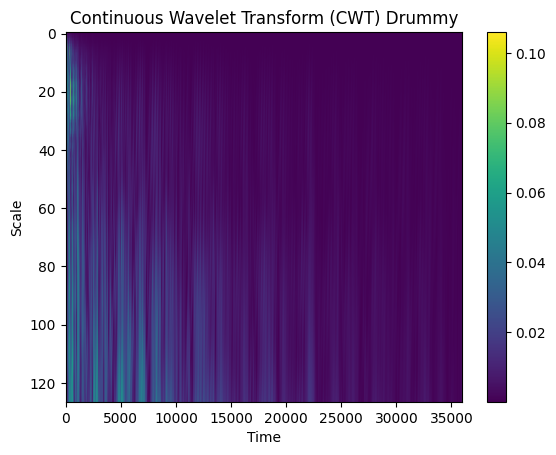

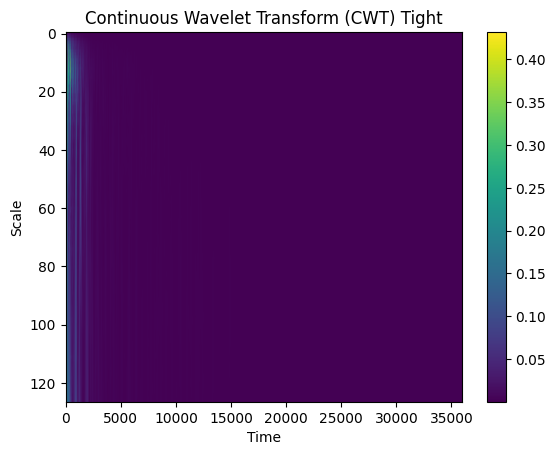

In [3]:
cwt = pywt.cwt(df.iloc[1, :-1].values, wavelet='cmor', scales=range(1,128))
cwt_1 = pywt.cwt(df.iloc[-1, :-1].values, wavelet='cmor', scales=range(1,128), axis=0)

#display cwt with matplotlib
import matplotlib.pyplot as plt
plt.imshow(np.abs(cwt[0]), aspect='auto')
plt.colorbar()
plt.title('Continuous Wavelet Transform (CWT) Drummy')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()

plt.imshow(np.abs(cwt_1[0]), aspect='auto')
plt.colorbar()
plt.title('Continuous Wavelet Transform (CWT) Tight')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()




In [ ]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


data = Extract_Features(
    df_X = df_X.iloc[:500],
    df_Y = df_Y.iloc[:500],
    feature = "wave_transform",
    wavelet = "cmor",
    scales = 64,
    num_frames = 400
)

print(data.get_samples().shape)
print(data.get_labels().shape)

Processing samples 0 to 500...


/Users/kanwarsingh/Desktop/AI/acoustic_signal_classification/venv/lib/python3.13/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)
